# SAM 3 automatic mask generation on clean grain images

This notebook runs **Meta's Segment Anything Model 3 (SAM 3)** on clean (etched, high-contrast)
grain images using **only the built-in automatic mask generator** — no point/box/text prompts,
no `segmenteverygrain` U-Net seeding, no DBSCAN prompt generation. It is a baseline to see how
well an off-the-shelf, class-agnostic model segments grains with zero task-specific tuning.

SAM 3 is served through the Hugging Face `transformers` `mask-generation` pipeline
(`facebook/sam3`). Automatic mode tiles a grid of points over the whole image, predicts a mask
at every point, then de-duplicates and quality-filters them. It is memory intensive, so start
with a single image before batching.

**References**
- SAM 3: Segment Anything with Concepts — https://ai.meta.com/research/publications/sam-3-segment-anything-with-concepts/
- Model card: https://huggingface.co/facebook/sam3
- Docs: https://huggingface.co/docs/transformers/en/model_doc/sam3_tracker

## 1. Setup

SAM 3 requires a recent `transformers` (>= 5.12). Uncomment and run once if needed. The model
weights are gated on the Hub — you must accept the license at https://huggingface.co/facebook/sam3
and be logged in (`huggingface-cli login`) the first time you download them.

In [1]:
# !pip install -U "transformers>=5.12" torch torchvision pillow matplotlib numpy
# !huggingface-cli login

In [29]:
import glob
import os

# Load SAM 3 from the local cache and skip the Hugging Face Hub metadata check.
# facebook/sam3 is a gated repo: once the weights are cached, an expired / re-gated token makes
# pipeline(...) raise a 401/403 on its pre-load Hub check instead of falling back to the cache
# (this is what killed the overnight run). Offline mode sidesteps that entirely.
# NOTE: comment these two lines out if you ever need to re-download or update the weights.
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"

import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image
from transformers import pipeline

# Pick the best available device: CUDA GPU, Apple Silicon (MPS), or CPU.
if torch.cuda.is_available():
    device = "cuda"
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f"Using device: {device}")

Using device: mps


## 2. Load the SAM 3 automatic mask generator

The `mask-generation` pipeline wraps SAM 3's automatic (prompt-free) mode. This downloads the
weights on first run and caches them under `~/.cache/huggingface`.

In [30]:
generator = pipeline("mask-generation", model="facebook/sam3", device=device)
print("SAM 3 automatic mask generator ready.")

Loading weights: 100%|██████████| 685/685 [00:00<00:00, 9982.27it/s]


SAM 3 automatic mask generator ready.


### 2b. (Optional) Pick a fine-tuned mask decoder

Checkpoints from the `SAM3_finetune*.ipynb` runs can be loaded into the automatic pipeline's
mask decoder here; set `FINETUNED_DECODER = None` for stock SAM 3. Re-run this cell to switch —
it restores the stock weights first, so switching back and forth is safe.

⚠️ **Measured caveat**: the current checkpoints were fine-tuned on the *single-mask* prompt path
(`multimask_output=False`), which recalibrates the IoU-prediction head that automatic mask
generation uses to filter proposals. On `prac7_etched_099`, stock AMG scores F1 0.75 vs GT while
AMG with `sam3_decoder_clean_noaug_ft.pt` injected collapses to F1 0.30 (recall 0.20) — most
proposals fail the `pred_iou_thresh` gate. If you experiment with a fine-tuned decoder here,
lower `PRED_IOU_THRESH` substantially and check the mask counts. The fine-tuned decoders *do*
help on the prompted paths: `SAM3_interactive_edit.ipynb` (annotator) and
`sam3_mass_annotate.py --engine grid`.

In [31]:
import copy

# Pick a fine-tuned mask decoder, or None for stock SAM 3 weights. Available checkpoints:
#   models/sam3_decoder_alumina_ft.pt        6 original images + synthetic blur (arm D)
#   models/sam3_decoder_prac7_only_ft.pt     clean prac7 070/090 + synthetic blur (arm C)
#   models/sam3_decoder_wilson_only_ft.pt    blurry Wilson images only (arm B)
#   models/sam3_decoder_clean_noaug_ft.pt    clean prac7 incl. 030/040, no augmentation
#   models/sam3_decoder_all_plus_new_ft.pt   everything incl. 030/040 + synthetic blur
FINETUNED_DECODER = None

if "_stock_decoder_state" not in globals():     # snapshot stock weights once
    _stock_decoder_state = copy.deepcopy(generator.model.mask_decoder.state_dict())

generator.model.mask_decoder.load_state_dict(_stock_decoder_state)   # always reset first
if FINETUNED_DECODER:
    generator.model.mask_decoder.load_state_dict(
        torch.load(FINETUNED_DECODER, map_location=str(next(generator.model.parameters()).device)))
    print(f"pipeline decoder <- {FINETUNED_DECODER}   (see caveat above: relax PRED_IOU_THRESH)")
else:
    print("pipeline decoder <- stock facebook/sam3 weights")

pipeline decoder <- stock facebook/sam3 weights


In [32]:
def show_masks(image_np, masks, ax=None, alpha=0.5, draw_boundaries=True):
    """Overlay a list of boolean masks on an image with random colors."""
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(image_np)
    if len(masks) == 0:
        ax.set_title("No masks")
        ax.axis("off")
        return ax

    h, w = np.asarray(masks[0]).shape
    overlay = np.zeros((h, w, 4), dtype=float)
    rng = np.random.default_rng(0)
    # Draw largest masks first so small grains stay visible on top.
    for m in sorted(masks, key=lambda x: np.asarray(x).sum(), reverse=True):
        m = np.asarray(m, dtype=bool)
        color = np.concatenate([rng.random(3), [alpha]])
        overlay[m] = color
    ax.imshow(overlay)

    if draw_boundaries:
        for m in masks:
            ax.contour(np.asarray(m, dtype=float), levels=[0.5], colors="white", linewidths=0.5)

    ax.set_title(f"{len(masks)} grains (SAM 3 automatic)")
    ax.axis("off")
    return ax

## 3. Load a test image

Pick one clean image; everything below (`run_sam3`, the tiled run, and the comparisons) uses
`image` / `image_np` from this cell.

Note: percentile contrast stretching at load time was tested (raw vs stretched on 5 annotated
images) and made no measurable difference to SAM 3's label quality — its own preprocessing
handles global contrast — so images are loaded as-is. If you ever feed 16-bit TIFFs, rescale
them to 8-bit yourself first: PIL's `.convert("RGB")` mangles them.

testcleanimages/cropped_prac7_etched_011.tif: 1024x703


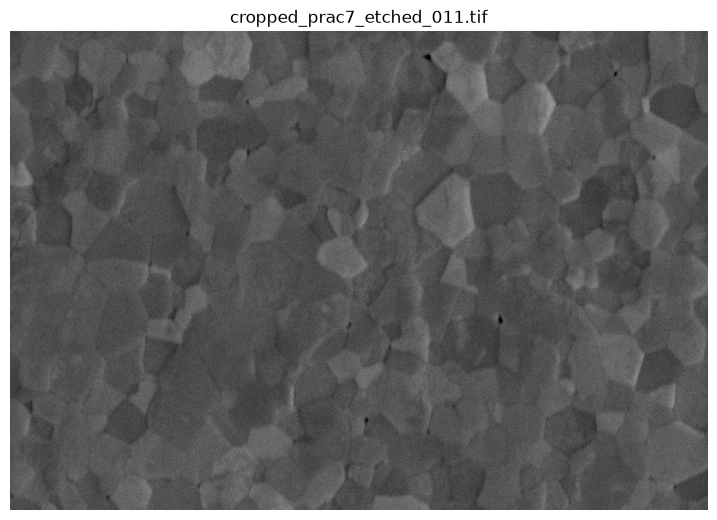

In [33]:
IMAGE_PATH = sorted(glob.glob("testcleanimages/*.tif"))[0]   # <-- pick your image here

image = Image.open(IMAGE_PATH).convert("RGB")
image_np = np.array(image)
print(f"{IMAGE_PATH}: {image.size[0]}x{image.size[1]}")

plt.figure(figsize=(9, 7))
plt.imshow(image_np)
plt.axis("off")
plt.title(os.path.basename(IMAGE_PATH))
plt.show()

Default knobs: 23 masks


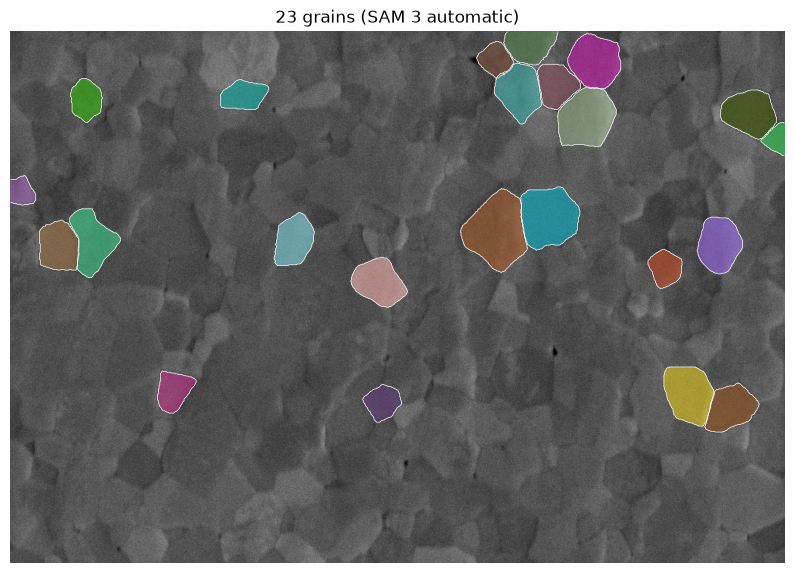

In [34]:
# Baseline: SAM 3 automatic mask generation with all-default knobs on the whole image.
# The tuned run and the tiled run in the next sections are compared against these `masks`.
out = generator(image, points_per_batch=64)
masks, scores = out["masks"], out["scores"]
print(f"Default knobs: {len(masks)} masks")
show_masks(image_np, masks)
plt.show()

Tuned whole-image run: 196 grains (defaults gave 23)


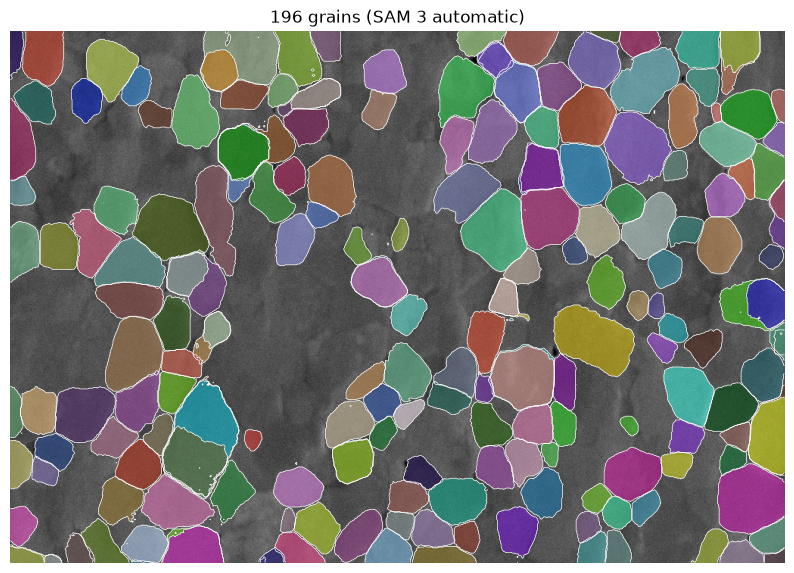

In [35]:
# ---- SAM 3 automatic-mask-generator knobs (all exposed) ----
# Defaults below are the best-F1 settings from the 10-image aggressiveness sweep
# (sam3_sweep_multi.py): points_per_crop=32, pred_iou_thresh=0.70 at stability_score_thresh=0.90.
# Recall goes up when you sample more points and relax the quality gates.
POINTS_PER_CROP         = 48    # grid density per (tile) image; biggest recall lever   (swept best; default 32)
POINTS_PER_BATCH        = 64    # points scored per forward pass; memory/speed only      (default 64)
PRED_IOU_THRESH         = 0.70  # drop masks below this predicted IoU; lower = more      (swept best; default 0.88)
STABILITY_SCORE_THRESH  = 0.90  # drop masks below this stability score; lower = more    (swept value; default 0.95)
STABILITY_SCORE_OFFSET  = 1.0   # offset used when computing the stability score         (default 1.0)
MASK_THRESHOLD          = 0.0   # logit threshold for binarizing masks                   (default 0.0)
CROPS_N_LAYERS          = 0     # SAM's own zoom-in crop layers; leave 0 when tiling      (default 0)
CROP_N_POINTS_DOWNSCALE = 2     # divide points_per_crop by this on each crop layer       (default 1)
CROP_OVERLAP_RATIO      = 0.34  # fractional overlap between SAM's internal crops         (default ~0.34)
CROPS_NMS_THRESH        = 0.70  # NMS IoU across crop results; higher = keep more overlap (default 0.7)

SAM3_KWARGS = dict(
    points_per_batch=POINTS_PER_BATCH,
    points_per_crop=POINTS_PER_CROP,
    pred_iou_thresh=PRED_IOU_THRESH,
    stability_score_thresh=STABILITY_SCORE_THRESH,
    stability_score_offset=STABILITY_SCORE_OFFSET,
    mask_threshold=MASK_THRESHOLD,
    crops_n_layers=CROPS_N_LAYERS,
    crop_n_points_downscale_factor=CROP_N_POINTS_DOWNSCALE,
    crop_overlap_ratio=CROP_OVERLAP_RATIO,
    crops_nms_thresh=CROPS_NMS_THRESH,
)


def run_sam3(img, **overrides):
    """Run SAM 3 automatic mask generation with the knobs above (override any per call).

    Landscape-bottom fix: SAM 3's automatic point grid only covers ~the top square of a
    non-square image, so on a wide (landscape) frame the bottom ~25-30% gets *no* masks at
    all. Verified this is positional (it survives a vertical flip) and not a threshold effect
    (permissive stability/pred_iou don't recover it) -- the masks are simply never generated
    there. So we reflect-pad the image up to a square, segment that, then crop masks back to
    the original frame and drop any that fell entirely in the padded margin. This also fixes
    the tiled path, whose edge tiles are themselves non-square.
    """
    arr = np.asarray(img.convert("RGB")) if isinstance(img, Image.Image) else np.asarray(img)
    h, w = arr.shape[:2]
    s = max(h, w)
    padded = np.pad(arr, ((0, s - h), (0, s - w), (0, 0)), mode="reflect")
    out = generator(Image.fromarray(padded), **{**SAM3_KWARGS, **overrides})
    masks, scores = [], []
    for m, sc in zip(out["masks"], out["scores"]):
        m = np.asarray(m, dtype=bool)[:h, :w]
        if m.any():  # discard masks that fell entirely in the reflected padding
            masks.append(m)
            scores.append(float(sc))
    return masks, np.asarray(scores)


# Whole-image run with the tuned settings (image is reflect-padded to a square first so the
# bottom of the frame is segmented; SAM then downscales the square to ~1008 px internally):

masks_aggr, scores_aggr = run_sam3(image)
print(f"Tuned whole-image run: {len(masks_aggr)} grains (defaults gave {len(masks)})")
show_masks(image_np, masks_aggr)
plt.show()

## 8. Tiled segmentation — avoid SAM's internal downscaling

SAM 3 resizes the whole image to ~1008 px before it samples points, so in a large SEM image the
smaller grains are gone before segmentation even starts. Splitting the image into **overlapping
tiles that are each ≤ ~1008 px** keeps every tile at native resolution, so SAM sees fine grains
clearly. This is the same idea as `crops_n_layers`, but done explicitly so you control tile size
and overlap.

`segment_tiled` below:
1. cuts the image into overlapping tiles (`TILE_SIZE`, `OVERLAP`),
2. runs `run_sam3` on each tile with the knobs from section 7,
3. drops masks touching an *interior* tile edge (partial grains — the overlap ensures a neighbor
   tile holds the whole grain), and
4. merges everything with NMS (`NMS_IOU`) to remove duplicates in the overlap zones.

Set `OVERLAP` larger than your biggest grain so nothing is lost at a seam. Note this holds every
mask as a full-image boolean array, so very large images × many grains use a lot of RAM — reduce
`TILE_SIZE`/increase step, or downcast, if memory is tight.

In [8]:
def _bbox(m):
    ys, xs = np.where(m)
    return xs.min(), ys.min(), xs.max() + 1, ys.max() + 1


def _bbox_overlap(a, b):
    return not (a[2] <= b[0] or b[2] <= a[0] or a[3] <= b[1] or b[3] <= a[1])


def _iou(a, b):
    inter = np.count_nonzero(a & b)
    if inter == 0:
        return 0.0
    return inter / np.count_nonzero(a | b)


def nms_masks(masks, scores, iou_thresh=0.7):
    """Greedy non-max suppression over boolean masks, highest score first."""
    if not masks:
        return [], np.array([])
    boxes = [_bbox(m) for m in masks]
    order = np.argsort(scores)[::-1]
    suppressed = np.zeros(len(masks), dtype=bool)
    keep = []
    for i in order:
        if suppressed[i]:
            continue
        keep.append(i)
        for j in order:
            if j == i or suppressed[j]:
                continue
            if _bbox_overlap(boxes[i], boxes[j]) and _iou(masks[i], masks[j]) > iou_thresh:
                suppressed[j] = True
    return [masks[i] for i in keep], scores[np.array(keep)]


def segment_tiled(image, tile_size=1000, overlap=250, nms_iou=0.7, **overrides):
    """Segment a large image tile-by-tile so SAM never downscales it.

    Each tile is <= tile_size (so no internal downscaling) and is segmented
    independently with `run_sam3`. Masks touching a tile edge that is *not* the
    image edge are dropped as partial grains -- the overlap guarantees the whole
    grain is captured by a neighboring tile -- then the survivors are merged with
    NMS to remove duplicates from the overlap regions.
    """
    image_np = np.asarray(image.convert("RGB")) if isinstance(image, Image.Image) else np.asarray(image)
    H, W = image_np.shape[:2]

    def origins(length, tile, step):
        if tile >= length:
            return [0]
        pts = list(range(0, length - tile + 1, step))
        if pts[-1] != length - tile:
            pts.append(length - tile)  # clamp the last tile flush to the edge
        return pts

    th, tw = min(tile_size, H), min(tile_size, W)
    ys, xs = origins(H, th, th - overlap), origins(W, tw, tw - overlap)

    all_masks, all_scores = [], []
    for y0 in ys:
        for x0 in xs:
            tile = image_np[y0:y0 + th, x0:x0 + tw]
            m_list, s_list = run_sam3(Image.fromarray(tile), **overrides)
            for m, s in zip(m_list, s_list):
                m = np.asarray(m, dtype=bool)
                touches_interior_edge = (
                    (m[0, :].any() and y0 > 0)
                    or (m[-1, :].any() and y0 + th < H)
                    or (m[:, 0].any() and x0 > 0)
                    or (m[:, -1].any() and x0 + tw < W)
                )
                if touches_interior_edge:
                    continue
                full = np.zeros((H, W), dtype=bool)
                full[y0:y0 + th, x0:x0 + tw] = m
                all_masks.append(full)
                all_scores.append(float(s))

    print(f"  {len(ys)}x{len(xs)} tiles -> {len(all_masks)} masks before NMS")
    merged, merged_scores = nms_masks(all_masks, np.asarray(all_scores), iou_thresh=nms_iou)
    print(f"  -> {len(merged)} masks after NMS")
    return merged, merged_scores

  1x2 tiles -> 354 masks before NMS
  -> 191 masks after NMS

Tiled total : 191 grains
Whole-image : 176 grains (aggressive)
Defaults    : 24 grains


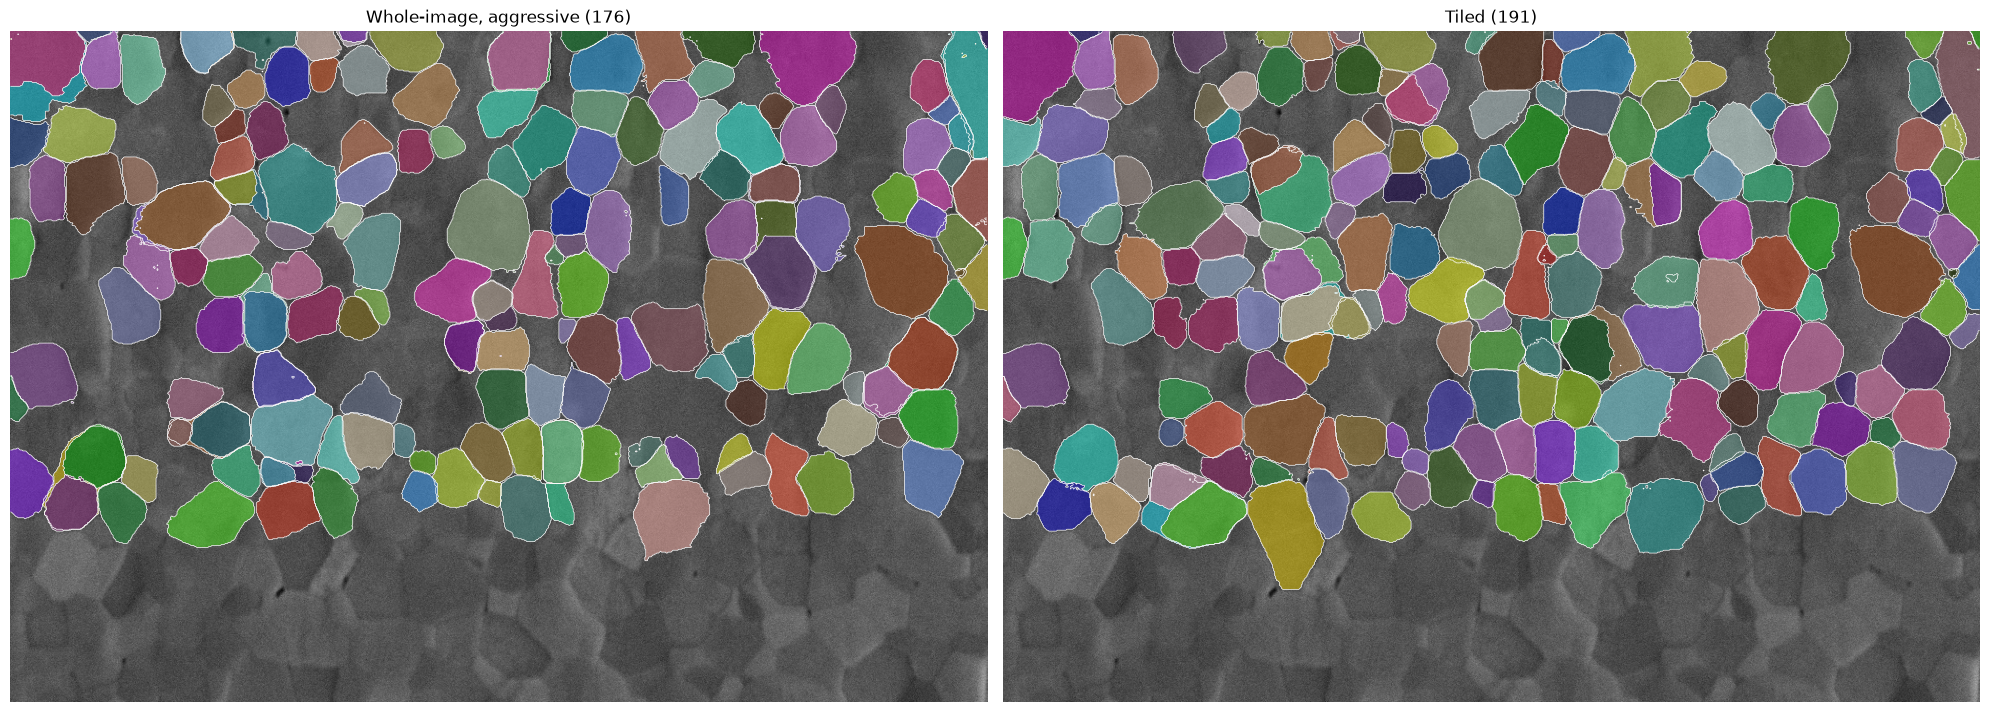

In [9]:
TILE_SIZE = 1000   # <= ~1008 keeps each tile at native resolution (no SAM downscaling)
OVERLAP   = 250    # should exceed the largest grain diameter so no grain is lost at a seam
NMS_IOU   = 0.7    # IoU above which two masks from overlapping tiles are treated as duplicates

masks_tiled, scores_tiled = segment_tiled(
    image, tile_size=TILE_SIZE, overlap=OVERLAP, nms_iou=NMS_IOU,
    crops_n_layers=0,  # tiling replaces SAM's internal cropping, so disable it here
)
print(f"\nTiled total : {len(masks_tiled)} grains")
print(f"Whole-image : {len(masks_aggr)} grains (aggressive)")
print(f"Defaults    : {len(masks)} grains")

fig, axes = plt.subplots(1, 2, figsize=(20, 10))
show_masks(image_np, masks_aggr, ax=axes[0])
axes[0].set_title(f"Whole-image, aggressive ({len(masks_aggr)})")
show_masks(image_np, masks_tiled, ax=axes[1])
axes[1].set_title(f"Tiled ({len(masks_tiled)})")
plt.tight_layout()
plt.show()

## 7. (Optional) Batch over a folder of clean images

Runs the same prompt-free segmentation across every image in a folder and saves an overlay PNG
plus the grain count for each. Set `SAVE_DIR` to keep the outputs.

In [ ]:
BATCH_DIR = "testcleanimages"
SAVE_DIR = "sam3_clean_grain_outputs"
MAX_IMAGES = None  # set to None to process the whole folder

os.makedirs(SAVE_DIR, exist_ok=True)
paths = sorted(glob.glob(os.path.join(BATCH_DIR, "*.tif")))
if MAX_IMAGES is not None:
    paths = paths[:MAX_IMAGES]

results = {}
for p in paths:
    img = Image.open(p).convert("RGB")
    masks_b, _ = run_sam3(img)  # tuned knobs + landscape-bottom fix (see section 7)
    n = len(masks_b)
    results[os.path.basename(p)] = n

    fig, ax = plt.subplots(figsize=(10, 10))
    show_masks(np.array(img), masks_b, ax=ax)
    stem = os.path.splitext(os.path.basename(p))[0]
    fig.savefig(os.path.join(SAVE_DIR, f"{stem}_sam3_overlay.png"), bbox_inches="tight", dpi=150)
    plt.close(fig)
    print(f"{os.path.basename(p)}: {n} grains")

print("\nGrain counts:", results)

## 9. Auto-annotate a folder into U-Net training masks

Turn SAM 3's per-grain masks into single-channel label images matching this project's
convention, **plus an ignore class**:

`0` = background   `1` = grain interior   `2` = grain boundary   `3` = **ignore**

`create_labeled_image` produces 0/1/2; here we add `3` for pixels SAM didn't cover. Because
`tf.one_hot(mask, depth=3)` maps `3 → [0,0,0]`, `weighted_crossentropy` gives those pixels zero
weight, so the loss simply **skips** them (no gradient) — the model is neither rewarded nor
penalised for what it predicts there. That's the right treatment for "grains are probably here
but can't be resolved", and it avoids teaching the model that grain-like texture is background.
**No change to the loss, patching, or augmentation is needed** — the value flows through untouched
(mask augmentation is flip-only; patch export preserves raw pixel values).

Each source image is written as a `{stem}_image.tif` + `{stem}_mask.tif` pair into `ANNOT_DIR`,
a drop-in `input_dir` for `seg.patchify_training_data(ANNOT_DIR, patch_dir)`.

**This SAM auto path defaults every uncovered pixel to ignore (`3`).** For the harder Wilson
images, label those by hand so you can decide true background (`0`) vs ignore (`3`) yourself.

In [ ]:
import shutil
from scipy import ndimage

# Semantic class codes. 0/1/2 match this project's hand masks / create_labeled_image;
# 3 = "ignore": tf.one_hot(3, depth=3) -> [0,0,0], so weighted_crossentropy gives those pixels
# zero weight and the loss skips them (no gradient). Use it for regions where grains are probably
# present but can't be resolved, so the model is neither rewarded nor penalised there -- instead
# of being wrongly taught that grain-like texture is "background".
BACKGROUND, GRAIN_INTERIOR, GRAIN_BOUNDARY, IGNORE = 0, 1, 2, 3


def masks_to_label_mask(masks, image_shape, boundary_width=2, unlabeled=IGNORE):
    """Convert SAM 3's list of boolean instance masks into a single-channel semantic
    label image, using segmenteverygrain's class convention plus an ignore label:

        0 = background          2 = grain boundary
        1 = grain interior      3 = ignore (loss skips these pixels)

    Pixels no grain covers get `unlabeled` (default IGNORE=3): for SAM pseudo-labels an
    uncovered pixel means "SAM found no grain here", which is uncertainty, not background --
    so by default we ignore it rather than teach the model it is background. Pass
    unlabeled=BACKGROUND if you trust coverage and want uncovered pixels treated as class 0.

    Boundaries are the ~boundary_width-px band straddling each grain's outline (raster
    equivalent of grain.boundary.buffer), painted over the interiors so touching grains stay
    separated -- that separation is what teaches the U-Net to split adjacent grains.
    """
    h, w = image_shape[:2]
    label = np.full((h, w), unlabeled, dtype=np.uint8)
    for m in masks:                                        # interiors first
        label[np.asarray(m, dtype=bool)] = GRAIN_INTERIOR
    for m in masks:                                        # boundaries painted on top
        m = np.asarray(m, dtype=bool)
        if not m.any():
            continue
        band = (ndimage.binary_dilation(m, iterations=boundary_width)
                & ~ndimage.binary_erosion(m, iterations=boundary_width))
        label[band] = GRAIN_BOUNDARY
    return label

: 

In [ ]:
import gc

# ---- Auto-annotate every image in SRC_DIR into U-Net training pairs (resumable) ----
SRC_DIR   = "testcleanimages"
ANNOT_DIR = "testcleanimages_sam3_auto"          # {stem}_image.tif + {stem}_mask.tif land here
BOUNDARY_WIDTH = 2
# Recall-leaning knobs for pseudo-labelling. Pixels SAM misses are marked IGNORE (3), so the loss
# skips them -- a low-coverage image just trains on less, it is not mislabelled -- but more
# coverage still means more usable supervision, so we lean toward recall over the F1-optimal 32/0.70.
# (Wilson images: label those by hand so you set true background=0 vs ignore=3 yourself; this SAM
# auto path defaults every uncovered pixel to ignore.)
ANNOT_KWARGS = dict(points_per_crop=64, pred_iou_thresh=0.60)

os.makedirs(ANNOT_DIR, exist_ok=True)
qc_dir = os.path.join(ANNOT_DIR, "qc_overlays")
os.makedirs(qc_dir, exist_ok=True)


def free_memory():
    """Release this image's allocations before the next one. Python won't hand it all back to the
    OS, but this reclaims the bulk -- most importantly the MPS/CUDA cache, the usual source of
    growth across a long SAM loop (and the likely cause of the overnight kernel death)."""
    gc.collect()
    if hasattr(torch, "mps") and torch.backends.mps.is_available():
        torch.mps.empty_cache()
    elif torch.cuda.is_available():
        torch.cuda.empty_cache()


src_paths = sorted(glob.glob(os.path.join(SRC_DIR, "*.tif")))
print(f"Annotating {len(src_paths)} images  {SRC_DIR}/ -> {ANNOT_DIR}/  (knobs={ANNOT_KWARGS})\n")

summary = []
for i, p in enumerate(src_paths, 1):
    stem = os.path.splitext(os.path.basename(p))[0]
    mask_path = os.path.join(ANNOT_DIR, f"{stem}_mask.tif")

    if os.path.exists(mask_path):                                  # resume: this image is already done
        ign = float((np.array(Image.open(mask_path)) == IGNORE).mean())
        summary.append((stem, None, ign))
        print(f"[{i:>2}/{len(src_paths)}] {stem}: already done, skipping (ignored={ign:.0%})")
        continue

    img = Image.open(p).convert("RGB")
    masks, _ = run_sam3(img, **ANNOT_KWARGS)                       # square-padded run (bottom covered)
    label = masks_to_label_mask(masks, np.array(img).shape,
                                boundary_width=BOUNDARY_WIDTH, unlabeled=IGNORE)  # uncovered -> ignore

    shutil.copyfile(p, os.path.join(ANNOT_DIR, f"{stem}_image.tif"))  # image half of the pair
    Image.fromarray(label, mode="L").save(mask_path)                 # 1/2/3 mask -- written LAST, it is the resume marker

    ign = float((label == IGNORE).mean())
    summary.append((stem, len(masks), ign))

    fig, ax = plt.subplots(figsize=(8, 8))                         # QC overlay to eyeball later
    show_masks(np.array(img), masks, ax=ax)
    fig.savefig(os.path.join(qc_dir, f"{stem}_overlay.png"), bbox_inches="tight", dpi=110)
    plt.close(fig)

    flag = "   <-- lots ignored, check coverage" if ign > 0.25 else ""
    print(f"[{i:>2}/{len(src_paths)}] {stem}: {len(masks):>3} grains, ignored={ign:.0%}{flag}")

    del img, masks, label, fig, ax                                 # drop refs, then free the MPS/CUDA cache
    #free_memory()

igns = [g for _, _, g in summary]
print(f"\nDone. {len(summary)} image/mask pairs in {ANNOT_DIR}/  (classes: 1=interior, 2=boundary, 3=ignore)")
print(f"Ignored (uncovered) fraction: median {np.median(igns):.0%}, worst {max(igns):.0%} "
      f"({sum(g > 0.25 for g in igns)} images > 25% -- high means SAM under-detected; raise ppc or drop them).")
print(f"Next: image_dir, mask_dir = seg.patchify_training_data('{ANNOT_DIR}', 'sam3_auto_patches/')")

Annotating 89 images  testcleanimages/ -> testcleanimages_sam3_auto/  (knobs={'points_per_crop': 64, 'pred_iou_thresh': 0.6})

[ 1/89] cropped_prac7_etched_011: already done, skipping (ignored=35%)
[ 2/89] cropped_prac7_etched_012: already done, skipping (ignored=35%)
[ 3/89] cropped_prac7_etched_013: already done, skipping (ignored=30%)
[ 4/89] cropped_prac7_etched_014: already done, skipping (ignored=26%)
[ 5/89] cropped_prac7_etched_015: already done, skipping (ignored=42%)
[ 6/89] cropped_prac7_etched_016: already done, skipping (ignored=36%)
[ 7/89] cropped_prac7_etched_017: already done, skipping (ignored=27%)
[ 8/89] cropped_prac7_etched_018: already done, skipping (ignored=31%)
[ 9/89] cropped_prac7_etched_019: already done, skipping (ignored=29%)
[10/89] cropped_prac7_etched_020: already done, skipping (ignored=28%)
[11/89] cropped_prac7_etched_021: already done, skipping (ignored=38%)
[12/89] cropped_prac7_etched_022: already done, skipping (ignored=20%)
[13/89] cropped_prac7